In [1]:
from google.colab import userdata
import os
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [2]:
!kaggle datasets download -d sumanthvrao/daily-climate-time-series-data

Dataset URL: https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data
License(s): CC0-1.0
daily-climate-time-series-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
! unzip "daily-climate-time-series-data.zip"

Archive:  daily-climate-time-series-data.zip
replace DailyDelhiClimateTest.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: DailyDelhiClimateTest.csv  
replace DailyDelhiClimateTrain.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: DailyDelhiClimateTrain.csv  


In [4]:
import pandas as pd

# Data Preparation and Exploration

Objective: Prepare the dataset for time series analysis and explore key climate variables.

In [5]:
train_df = pd.read_csv("DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("DailyDelhiClimateTest.csv")

In [6]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


Handle missing values: Use appropriate methods to fill or remove them.

In [9]:
train_df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [10]:
test_df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


Check data types: Ensure the date column is in datetime format and numerical columns are appropriately formatted.

In [11]:
train_df['formated_date'] = pd.to_datetime(train_df['date'])
test_df['formated_date'] = pd.to_datetime(test_df['date'])

# ChatGPT Application

### Interpolation Methods and Their Impact on Time Series Analysis

Interpolation is a technique used in time series analysis to estimate missing or unknown values between observed data points. The choice of interpolation method can significantly impact the analysis, especially in climate data where precision is crucial.

#### 1. **Linear Interpolation**
   - **Method**: Estimates missing values by connecting two adjacent points with a straight line.
   - **Impact**:
     - Simple and fast.
     - Suitable when data changes at a constant rate.
     - May not capture non-linear trends, potentially leading to inaccuracies if the underlying data has a non-linear pattern.
   - **Use Case**: Temperature data with consistent changes over time.

#### 2. **Polynomial Interpolation**
   - **Method**: Fits a polynomial of a specified degree to the data points.
   - **Impact**:
     - Can capture more complex trends.
     - Higher-degree polynomials can lead to overfitting, causing large oscillations between points, especially with sparse data.
   - **Use Case**: Climate variables that exhibit seasonal trends, like precipitation.

#### 3. **Spline Interpolation**
   - **Method**: Fits piecewise polynomials (usually cubic) between each pair of points, ensuring smooth transitions at each data point.
   - **Impact**:
     - Provides a smooth curve that can handle both linear and non-linear data.
     - Reduces the risk of overfitting compared to high-degree polynomials.
     - May introduce small oscillations in rapidly changing data.
   - **Use Case**: Long-term temperature records where smooth trends are expected.

#### 4. **Nearest Neighbor Interpolation**
   - **Method**: Fills missing values with the nearest available data point.
   - **Impact**:
     - Simple but can create abrupt changes in the data.
     - May distort analysis by introducing step-like artifacts.
   - **Use Case**: Rarely used in climate data, except when data is very sparse, and preserving original values is crucial.

#### 5. **LOESS (Local Regression)**
   - **Method**: Fits multiple low-degree polynomials to local subsets of the data.
   - **Impact**:
     - Effective in capturing complex, non-linear trends.
     - Computationally intensive.
     - Smooths out noise but can also smooth out important fluctuations if not carefully tuned.
   - **Use Case**: Analyzing climate data with localized trends, such as urban temperature variations.

### Outlier Detection and Treatment in Climate Data

Outliers in climate data can arise due to measurement errors, extreme weather events, or data entry mistakes. Identifying and treating outliers is essential for accurate analysis and forecasting.

#### 1. **Methods for Outlier Detection**
   - **Z-Score Method**:
     - Calculates the number of standard deviations a data point is from the mean.
     - **Impact**: Effective for normally distributed data. Outliers are typically considered to be data points with a Z-score greater than 3 or less than -3.
     - **Limitation**: Less effective in non-Gaussian distributions, common in climate data.

   - **Interquartile Range (IQR) Method**:
     - Identifies outliers as data points beyond 1.5 times the IQR from the first and third quartiles.
     - **Impact**: Robust for skewed distributions. More reliable for climate data, which often has non-normal distributions.
     - **Limitation**: May miss extreme values that are legitimate and significant.

   - **Time Series Decomposition**:
     - Decomposes data into trend, seasonality, and residual components. Outliers are detected in the residual component.
     - **Impact**: Can identify outliers that are deviations from the expected trend or seasonal pattern.
     - **Limitation**: Requires a well-defined model of the time series components.

   - **Machine Learning Techniques**:
     - Algorithms like Isolation Forest, DBSCAN, or clustering methods detect outliers by understanding data patterns.
     - **Impact**: Powerful in handling complex datasets with multiple variables.
     - **Limitation**: Requires significant computational resources and careful tuning to avoid false positives.

#### 2. **Treatment of Outliers**
   - **Removal**: Deleting outliers if they are determined to be erroneous data points (e.g., sensor malfunction).
     - **Impact**: Improves the accuracy of analysis but may lead to loss of valuable data if misapplied.
   
   - **Capping and Flooring**: Replacing outliers with the nearest non-outlier value within a defined threshold.
     - **Impact**: Retains the structure of the data while mitigating the impact of extreme values.
   
   - **Imputation**: Replacing outliers with estimates using interpolation or other statistical methods.
     - **Impact**: Helps maintain continuity in time series but may introduce bias if the imputation method is not appropriate for the data distribution.
   
   - **Transformation**: Applying transformations (e.g., logarithmic) to reduce the impact of outliers.
     - **Impact**: Can stabilize variance and reduce the influence of extreme values, improving model performance in some cases.

### Conclusion
The choice of interpolation and outlier treatment methods in climate data analysis is crucial and should be made considering the nature of the data and the specific analysis goals. Each method has its strengths and weaknesses, and the impact on the final results can be significant.

**Interpolation Methods in Time Series Analysis and Their Impact**

Interpolation is a technique used to estimate missing or unknown values within a sequence of data points. In time series analysis, interpolation helps in creating a continuous dataset from discrete observations, which is crucial for various analytical methods like forecasting, trend analysis, and modeling. Different interpolation methods can significantly affect the results of time series analysis. Below are some common interpolation methods and their impacts:

### 1. **Linear Interpolation**

- **Method**: Connects two known data points with a straight line and estimates missing values along that line.
- **Impact**:
  - **Advantages**: Simple to implement; works well when data changes are approximately linear between points.
  - **Disadvantages**: May not capture underlying trends or seasonal patterns; can introduce bias if the actual data is nonlinear.

### 2. **Polynomial Interpolation**

- **Method**: Fits a polynomial of degree *n* to *n+1* data points and uses it to estimate missing values.
- **Impact**:
  - **Advantages**: Can capture more complex relationships in the data compared to linear interpolation.
  - **Disadvantages**: Prone to overfitting, especially with high-degree polynomials; can produce oscillations between data points (Runge's phenomenon).

### 3. **Spline Interpolation**

- **Method**: Uses piecewise polynomials (usually cubic) to fit between data points, ensuring smoothness at the knots (data points).
- **Impact**:
  - **Advantages**: Provides a smooth curve that is more flexible than linear interpolation; reduces oscillations seen in high-degree polynomials.
  - **Disadvantages**: Computationally more complex; may still not capture sudden changes in data.

### 4. **Time-Series Specific Interpolation**

- **Method**: Considers the temporal aspect of data. Examples include:
  - **Time-Weighted Interpolation**: Gives more weight to closer time points.
  - **Last Observation Carried Forward (LOCF)**: Uses the last known value to fill subsequent missing values.
  - **Next Observation Carried Backward (NOCB)**: Uses the next known value for previous missing data.
- **Impact**:
  - **Advantages**: Preserves the time-dependent structure; useful for non-stationary data.
  - **Disadvantages**: Methods like LOCF can introduce bias, especially if the data is highly variable.

### 5. **Kriging (Geostatistical Interpolation)**

- **Method**: Uses spatial autocorrelation to predict missing values; often used in environmental sciences.
- **Impact**:
  - **Advantages**: Accounts for spatial and temporal correlation; provides estimates of interpolation uncertainty.
  - **Disadvantages**: Requires assumptions about the data's spatial structure; computationally intensive.

### 6. **Fourier and Wavelet Interpolation**

- **Method**: Decomposes the time series into frequency components and reconstructs missing values.
- **Impact**:
  - **Advantages**: Captures periodic patterns and trends; useful for data with seasonality.
  - **Disadvantages**: May not handle non-stationary data well; requires careful selection of frequency components.

### 7. **Machine Learning Approaches**

- **Method**: Utilizes algorithms like K-Nearest Neighbors, Random Forests, or Neural Networks to predict missing values.
- **Impact**:
  - **Advantages**: Can model complex nonlinear relationships; adapts to various data patterns.
  - **Disadvantages**: Requires large datasets; risk of overfitting; less interpretable.

### **Impact on Time Series Analysis**

- **Bias and Variance**: Different interpolation methods can introduce bias or variance into the dataset, affecting the reliability of subsequent analyses.
- **Trend and Seasonality Detection**: Inaccurate interpolation can obscure or create artificial trends and seasonal patterns.
- **Forecasting Accuracy**: Models built on interpolated data may yield less accurate forecasts due to the propagation of interpolation errors.
- **Statistical Properties**: Interpolation can alter statistical properties like mean, variance, and autocorrelation, impacting model selection and hypothesis testing.

**Outlier Detection and Treatment in Climate Data**

Climate data often contains outliers due to instrument errors, extreme weather events, or data processing mistakes. Detecting and treating outliers is crucial for accurate climate modeling and analysis.

### **Outlier Detection Methods**

1. **Statistical Techniques**

   - **Z-Score Method**: Flags data points that are a certain number of standard deviations away from the mean.
     - **Limitations**: Assumes normal distribution; may not be suitable for skewed data.
   - **Modified Z-Score**: Uses median and median absolute deviation, which is more robust to outliers.
   - **Percentile-Based Methods**: Identifies data points outside a specified percentile range (e.g., below 1st percentile or above 99th percentile).

2. **Time Series Analysis**

   - **ARIMA Model Residuals**: Outliers can be detected by analyzing residuals from fitted time series models.
   - **Seasonal Decomposition**: Helps identify anomalies by separating seasonal and trend components.

3. **Machine Learning Techniques**

   - **Isolation Forest**: An unsupervised learning algorithm that isolates anomalies.
   - **Local Outlier Factor (LOF)**: Measures the local deviation of a data point with respect to its neighbors.

4. **Domain-Specific Rules**

   - **Physical Limits**: Applying known physical constraints (e.g., temperature cannot be below absolute zero).
   - **Consistency Checks**: Cross-validating with nearby stations or sensors.

### **Outlier Treatment Methods**

1. **Removal**

   - **Pros**: Simplifies analysis; removes data points that could skew results.
   - **Cons**: Risk of discarding valid extreme events; reduces data size.

2. **Imputation**

   - **Mean or Median Substitution**: Replaces outliers with the mean or median value.
     - **Limitation**: Can underestimate variability.
   - **Interpolation**: Uses neighboring data points to estimate a replacement value.
   - **Model-Based Imputation**: Predicts values using statistical or machine learning models.

3. **Capping (Winsorization)**

   - **Method**: Limits extreme values to a specified percentile value.
   - **Impact**: Reduces the influence of extreme outliers without removing them entirely.

4. **Transformation**

   - **Logarithmic or Box-Cox Transformations**: Reduces the impact of outliers by compressing the scale.
   - **Impact**: Alters the distribution; may complicate interpretation.

### **Best Practices**

- **Understand the Cause**: Before treating outliers, investigate their origins to distinguish between errors and significant events.
- **Document Decisions**: Keep records of the methods used for outlier detection and treatment for transparency.
- **Impact Assessment**: Evaluate how outlier treatment affects the analysis results, especially trends and variability.
- **Use Robust Methods**: Employ statistical techniques less sensitive to outliers, like median-based measures.

### **Implications for Climate Data Analysis**

- **Trend Analysis**: Outliers can distort trend estimations, leading to incorrect conclusions about climate change patterns.
- **Extreme Event Analysis**: Removing true extreme events (like heatwaves or cold snaps) can bias the analysis; such events are often of primary interest.
- **Model Calibration**: Outliers can affect the calibration of climate models, impacting their predictive capabilities.

**Conclusion**

The choice of interpolation method and outlier treatment strategy can significantly influence the outcomes of time series analysis, particularly in climate data where accurate representation of trends and variability is crucial. It's essential to select appropriate methods based on the data characteristics and the specific goals of the analysis.

**Recommendations**

- **For Interpolation**:
  - Analyze the data to understand its properties (stationarity, seasonality, trends).
  - Choose an interpolation method that aligns with the data's characteristics.
  - Validate the interpolated values using a subset of known data.

- **For Outlier Detection and Treatment**:
  - Combine multiple detection methods for robust identification.
  - Consider the context of the data to decide whether to treat or retain outliers.
  - Assess the impact of outlier treatment on the analysis results.

By carefully selecting interpolation and outlier treatment methods, you can enhance the quality of your time series analysis and derive more reliable insights from climate data.

# Data Exploration

Objective: Explore the temperature data to identify key characteristics like trends and seasonality.

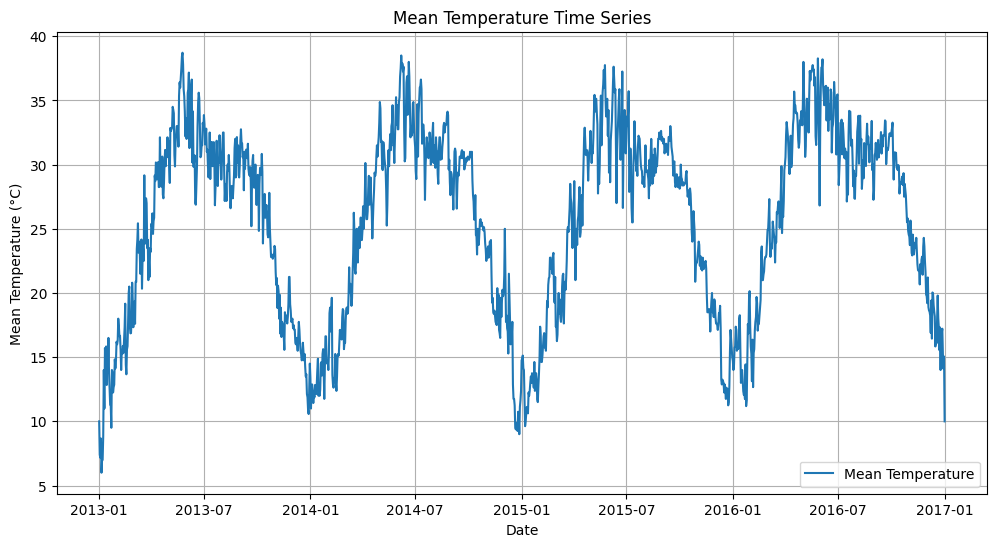

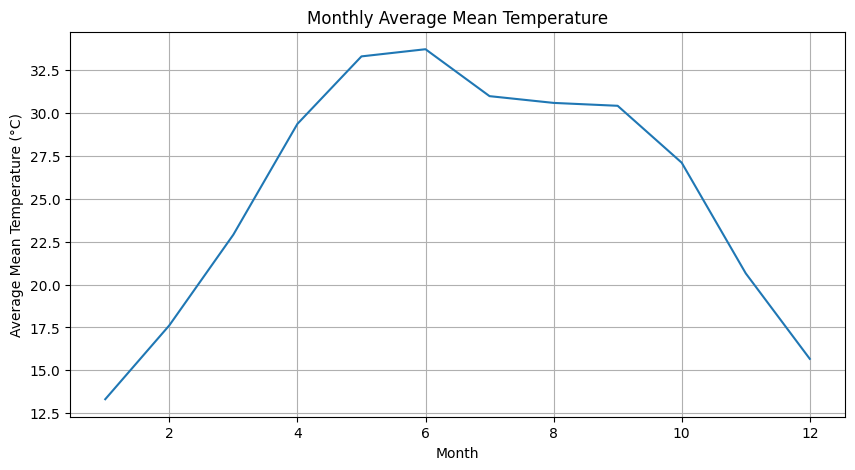

In [12]:
# prompt: Perform an exploratory data analysis to identify trends, seasonality, or irregular patterns.

import matplotlib.pyplot as plt

# Plot time series of temperature variables
plt.figure(figsize=(12, 6))
plt.plot(train_df['formated_date'], train_df['meantemp'], label='Mean Temperature')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.title('Mean Temperature Time Series')
plt.legend()
plt.grid(True)
plt.show()

# Explore seasonality (example with monthly mean temperature)
train_df['month'] = train_df['formated_date'].dt.month
monthly_mean_temp = train_df.groupby('month')['meantemp'].mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_mean_temp.index, monthly_mean_temp.values)
plt.xlabel('Month')
plt.ylabel('Average Mean Temperature (°C)')
plt.title('Monthly Average Mean Temperature')
plt.grid(True)
plt.show()

# Explore other variables and relationships as needed


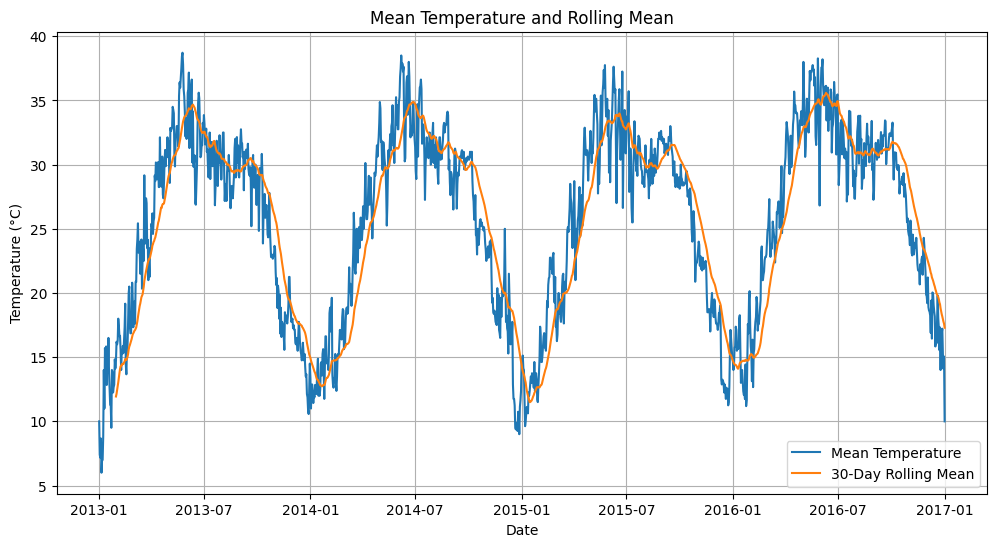

In [13]:
# prompt: Identify Trends using Pandas’ rolling() function.

import matplotlib.pyplot as plt
# Calculate rolling mean for a 30-day window
train_df['rolling_mean_temp'] = train_df['meantemp'].rolling(window=30).mean()

# Plot the rolling mean along with the original time series
plt.figure(figsize=(12, 6))
plt.plot(train_df['formated_date'], train_df['meantemp'], label='Mean Temperature')
plt.plot(train_df['formated_date'], train_df['rolling_mean_temp'], label='30-Day Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Mean Temperature and Rolling Mean')
plt.legend()
plt.grid(True)
plt.show()


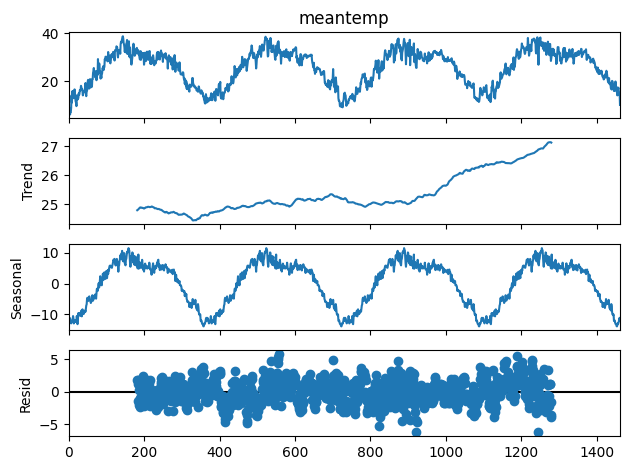

In [14]:
# prompt: Detect Seasonality with seasonal decomposition (seasonal_decompose from statsmodels.tsa.seasonal).

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
result = seasonal_decompose(train_df['meantemp'], model='additive', period=365)  # Assuming yearly seasonality

# Plot the decomposed components
result.plot()
plt.show()


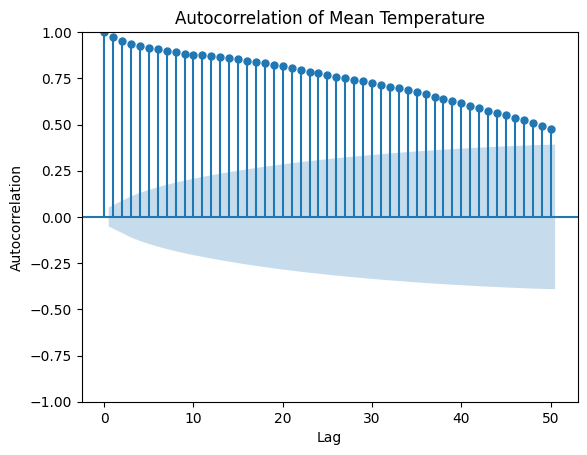

In [15]:
# prompt: Perform Autocorrelation Analysis using plot_acf() from statsmodels.graphics.tsaplots. and explain

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Perform autocorrelation analysis
plot_acf(train_df['meantemp'], lags=50)  # Adjust lags as needed
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Mean Temperature')
plt.show()

# Explanation:
# Autocorrelation analysis helps identify the correlation between a time series and its lagged versions.
# The plot shows the correlation coefficient for different lags.
# Significant correlations at certain lags indicate potential patterns or seasonality in the data.
# In this case, you would interpret the plot based on the peaks and their significance levels.


In [16]:
# prompt: implications of identified patterns for forecasting models. Formulate hypotheses about climatic trends and validate them

# Based on the identified patterns, formulate hypotheses about climatic trends.
# Example hypothesis: "There is a strong seasonal pattern in mean temperature with a peak in summer and a trough in winter."

# To validate the hypothesis, you can:
# 1. Analyze the seasonal component from the seasonal decomposition.
# 2. Compare the observed patterns with historical data or climate models.
# 3. Use statistical tests to assess the significance of the observed patterns.

# Example using statistical tests:
# - Test for seasonality using statistical tests like the Augmented Dickey-Fuller test.
# - Analyze the significance of the autocorrelation coefficients.

# Implications for forecasting models:
# - Seasonal patterns suggest that models like SARIMA (Seasonal Autoregressive Integrated Moving Average) might be suitable for forecasting.
# - Trends indicate the need for models that can capture long-term changes in temperature.
# - Autocorrelation suggests that past values of the time series can be used to predict future values.

# Further analysis:
# - Explore the relationship between mean temperature and other variables (e.g., rainfall, humidity).
# - Consider external factors like El Niño-Southern Oscillation (ENSO) or volcanic eruptions.
# - Use advanced forecasting techniques like machine learning models (e.g., LSTM, Prophet) to improve prediction accuracy.


# Time Series Forecasting

Objective: Build and evaluate a time series forecasting model.

In [17]:
train_data = train_df['meantemp']
test_data = test_df['meantemp']

In [18]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
import pmdarima as pm

In [47]:
model = ARIMA(train_data, order=(5, 1, 2))
model_fit = model.fit()
predictions = model_fit.forecast(steps=len(test_data))

In [48]:
print(predictions)

1462    11.338623
1463    12.027579
1464    12.776290
1465    12.918541
1466    13.061969
          ...    
1571    13.065699
1572    13.065699
1573    13.065699
1574    13.065699
1575    13.065699
Name: predicted_mean, Length: 114, dtype: float64


In [49]:
rmse = np.sqrt(mean_squared_error(test_data, predictions))
print(f'RMSE: {rmse}')

RMSE: 10.73003522208525


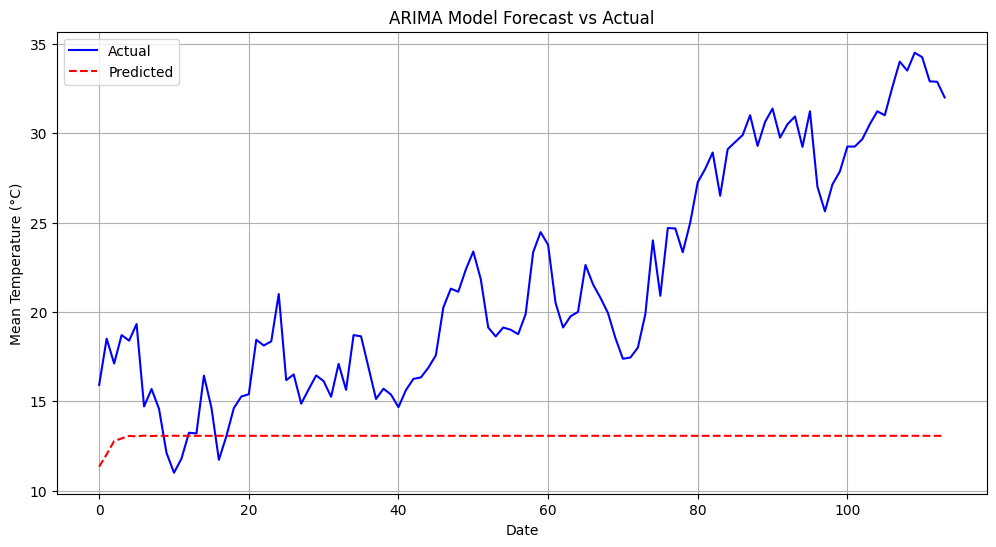

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data, label='Actual', color='blue')
plt.plot(test_data.index, predictions, label='Predicted', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.title('ARIMA Model Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()